<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB41 · Sensores y ruido

**Parte 5 · La física del cuerpo — Lección 6**

> En el **NB40** sostuviste a Hopper de pie con un controlador PD que, en cada pasito, leía sus ángulos (`datos.qpos`) y sus velocidades (`datos.qvel`).

Hay un detalle que no te conté: eso es **trampa**. `qpos` y `qvel` son los números **exactos** que el simulador usa para calcular la física. Un robot real **no tiene** esos números. Tiene **sensores**: aparatos que **miden**, y que, como todo lo que mide, se **equivocan un poco**. Sus medidas tienen **ruido** (pequeños errores al azar), **sesgos** (errores que siempre van hacia el mismo lado), **retrasos** y una **resolución** limitada.

En el mundo del RL para robots, a `qpos`, `qvel` y todo lo que el simulador sabe pero el robot real no puede medir se le llama **información privilegiada**. Entrenar una política que **depende** de información privilegiada es una de las formas más rápidas de que falle al pasar a un robot real (el **reality gap** del NB02).

Hoy vamos a conocer los sensores de un robot con patas, a entender qué miden **de verdad** y cómo se equivocan, y a aprender los trucos para sacar buena información de sensores imperfectos. Y terminaremos con un experimento que asusta: qué le pasa al Hopper campeón del NB35 cuando sus observaciones tienen un **poquito** de ruido.


## 1 · El codificador: contar rayas

El sensor más básico de un robot es el **codificador** (*encoder*): mide el **ángulo** de una articulación. El más común funciona así:

- Pegado al eje del motor hay un **disco** con muchas **rayas** finas (transparentes y opacas, alternadas), como los radios de una rueda.
- A un lado del disco hay una **lucecita**, y al otro, un **detector de luz**.
- Al girar el disco, el detector ve **luz, oscuridad, luz, oscuridad**... y un pequeño chip **cuenta** los cambios.

```
          detector
             ▼
      ╱ ╲ ╱ ╲ ╱ ╲ ╱ ╲        ← el disco, con rayas, gira
             ▲
           luz
```

Contando rayas se sabe cuánto ha girado. Un codificador típico tiene **4.096 posiciones por vuelta** (2¹², NB06... ¡potencias de 2 otra vez!). Eso significa que no puede medir **cualquier** ángulo, sino solo múltiplos de un "escalón" mínimo, su **resolución**:


In [1]:
import math

posiciones_por_vuelta = 4096
resolucion = 2 * math.pi / posiciones_por_vuelta
print(f"{resolucion:.5f} rad  =  {math.degrees(resolucion):.3f} grados")

0.00153 rad  =  0.088 grados


**0,088 grados**. Muy fino: para el ángulo, el codificador es un sensor excelente. Y como suele ir en el eje del **motor**, antes de la reductora (NB40), en la articulación es todavía N veces más fino.

### El problema: la velocidad

El PD del NB40 necesita también la **velocidad** de giro (el término D). El codificador **no** mide velocidades, solo ángulos. ¿Cómo se saca la velocidad? Con la **pendiente** del NB16: el ángulo de ahora menos el de antes, dividido entre el tiempo que ha pasado. Si el controlador mide 1.000 veces por segundo, cada 0,001 s:

```
   velocidad ≈ (ángulo ahora − ángulo hace 0,001 s) / 0,001
```

Parece inocente. Pero mira lo que pasa con una articulación que gira **suavemente** a 0,5 rad/s, medida con nuestro codificador. Primero, la medida: el ángulo de verdad, **redondeado** al escalón más cercano (es lo que hace el codificador). Una línea por idea:


In [2]:
import numpy as np

tiempo = np.arange(0, 0.05, 0.001)                         # 50 milisegundos, de milésima en milésima
angulo_real = 0.5 * tiempo                                  # gira a 0,5 rad/s, sin prisa
angulo_medido = np.round(angulo_real / resolucion) * resolucion    # redondeado a escalones de 0,0015 rad

(`np.round(x / escalón) * escalón` redondea x al múltiplo del escalón más cercano: cuántas rayas, por lo que mide cada raya.) Y ahora, la velocidad con la pendiente:

In [3]:
velocidad_medida = np.diff(angulo_medido) / 0.001
print(np.round(velocidad_medida[:15], 2))

[0.   1.53 0.   0.   1.53 0.   0.   1.53 0.   0.   1.53 0.   0.   1.53
 0.  ]


¡Horrible! La articulación gira suave a **0,5 rad/s**, pero la "velocidad medida" salta entre **0** y **1,53 rad/s**: durante unas milésimas, el disco no ha pasado ninguna raya (velocidad "cero") y de repente pasa una (velocidad "1,53", el escalón dividido entre 0,001 s). En **promedio** da 0,5, pero cada medida suelta es un disparate.

Esto es una lección general muy importante: **derivar** (calcular pendientes) **amplifica** los errores. Un error minúsculo en el ángulo (0,0015 rad) se convierte en un error enorme en la velocidad (1,53 rad/s), porque se divide entre un tiempo muy pequeño. Por eso, en el NB40, te avisé de que un Kd alto "amplifica el ruido de los sensores": el término D multiplica justo esta velocidad tan ruidosa. ¿Cómo se arregla? Hay que **suavizar**. Vamos a ver cómo.


## 2 · El ruido y cómo domarlo

Casi todos los sensores tienen **ruido**: pequeños errores **al azar** en cada medida, unas veces hacia arriba y otras hacia abajo. El ruido suele seguir la **campana** del NB28 (la distribución **normal** o **gaussiana**): la mayoría de los errores son pequeños, y los grandes son raros.

Simulemos un sensor que mide un valor de verdad de **1,0**, con ruido de desviación típica 0,1 (NB28: el "ancho" de la campana). Con NumPy, `rng.normal(media, desviación, cuántos)` saca números al azar de una campana:


In [4]:
rng = np.random.default_rng(0)                  # generador de azar con semilla, para que salga siempre igual (NB28)
medidas = 1.0 + rng.normal(0, 0.1, 10)
print(np.round(medidas, 3))

[1.013 0.987 1.064 1.01  0.946 1.036 1.13  1.095 0.93  0.873]


Diez medidas, todas cerca de 1, ninguna exactamente 1. Algunas se pasan, otras se quedan cortas.

### Truco 1: promediar

Si los errores son al azar, unos hacia arriba y otros hacia abajo, al **promediar** varias medidas se **compensan** en parte. ¿Cuánto? Hay una regla preciosa de la estadística: **promediando n medidas, el ruido se divide entre √n**. Promediar 4 medidas divide el ruido entre 2; promediar 100, entre 10. Comprobémoslo: repetimos 10.000 veces el experimento de promediar n medidas y miramos cuánto se desvían los promedios:


In [5]:
for n in [1, 4, 100]:
    promedios = (1.0 + rng.normal(0, 0.1, (10000, n))).mean(axis=1)
    print(f"promediando {n:3d} medidas: ruido {promedios.std():.4f}   (la regla dice 0,1 / √{n} = {0.1 / math.sqrt(n):.4f})")

promediando   1 medidas: ruido 0.0999   (la regla dice 0,1 / √1 = 0.1000)
promediando   4 medidas: ruido 0.0499   (la regla dice 0,1 / √4 = 0.0500)
promediando 100 medidas: ruido 0.0100   (la regla dice 0,1 / √100 = 0.0100)


(`rng.normal(0, 0.1, (10000, n))` crea una tabla de 10.000 filas con n medidas cada una, y `.mean(axis=1)` promedia cada fila: el `axis` del NB27.) La regla se cumple.

### Truco 2: la media móvil... y su precio

Un robot no puede esperar a tener 100 medidas del **mismo** instante: el mundo cambia. Lo que se hace es promediar las **últimas** medidas: una **media móvil** (como la "media de las últimas 10 notas"). Vamos a suavizar la velocidad horrible del codificador promediando las últimas 10 medidas. Esta vez, durante medio segundo, y con una articulación que **acelera** (su velocidad crece de 0 a 2 rad/s), para ver qué pasa cuando las cosas cambian:


In [6]:
tiempo = np.arange(0, 0.5, 0.001)
velocidad_real = 4 * tiempo                                  # la velocidad crece de 0 a 2 rad/s
angulo_real = 2 * tiempo ** 2                                # el ángulo que corresponde a esa velocidad
angulo_medido = np.round(angulo_real / resolucion) * resolucion
velocidad_medida = np.diff(angulo_medido) / 0.001

ventana = 10
velocidad_suavizada = np.convolve(velocidad_medida, np.ones(ventana) / ventana, mode="valid")

(`np.convolve` con una lista de 10 décimas hace justo eso: cada valor nuevo es la media de 10 seguidos. No hace falta entenderlo más allá de eso.) Dibujemos las tres velocidades, la real, la medida y la suavizada, en un trocito de 0,1 s:

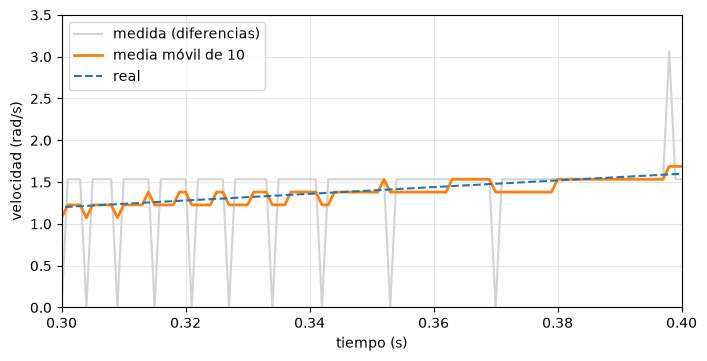

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3.8))
plt.plot(tiempo[1:], velocidad_medida, color="lightgray", label="medida (diferencias)")
plt.plot(tiempo[ventana:], velocidad_suavizada, color="tab:orange", lw=2, label=f"media móvil de {ventana}")
plt.plot(tiempo, velocidad_real, "--", color="tab:blue", label="real")
plt.xlim(0.3, 0.4)
plt.ylim(0, 3.5)
plt.xlabel("tiempo (s)")
plt.ylabel("velocidad (rad/s)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

La medida en bruto (gris) salta como loca entre 0, 1,5 y 3. La media móvil (naranja) es mucho más **suave** y sigue a la real. Pero fíjate bien: va un poquito **por debajo** de la real, como si fuera **con retraso**. Claro: está promediando las 10 últimas medidas, y las de hace 10 milisegundos eran más pequeñas (la velocidad estaba creciendo). La media móvil "llega tarde" unos 5 milisegundos (la mitad de su ventana).

Este es el gran **dilema** de los sensores: **suavizar más = menos ruido pero más retraso**. Y en la sección 7 veremos que el retraso puede ser **peor** que el ruido.


## 3 · La IMU: el oído interno del robot

Los codificadores dicen cómo está doblada cada articulación. Pero eso no basta: Hopper podría tener todas las articulaciones perfectas y estar **cayéndose de bruces**. Hace falta saber **cómo está orientado el cuerpo respecto del mundo**: ¿está el torso recto o inclinado? ¿Está girando?

Para eso, casi todos los robots llevan en el torso una **IMU** (*Inertial Measurement Unit*, "unidad de medida inercial"). Es el equivalente de tu **oído interno**, el órgano del equilibrio, que te dice si estás inclinado o girando aunque cierres los ojos. Una IMU tiene dos sensores (a veces tres), y cada uno se equivoca de una manera distinta.

### El acelerómetro: un peso con muelles

Imagina una **bolita** dentro de una cajita, sujeta por **muelles** a las paredes. Si la caja acelera hacia la derecha, la bolita "se queda atrás" (inercia, NB02) y estira los muelles: midiendo cuánto se estiran, sabemos la aceleración. Los acelerómetros de los móviles y de los robots son así, en miniatura (de una fracción de milímetro), grabados en silicio.

Y aquí viene lo sorprendente. Pon el acelerómetro **quieto** encima de la mesa. ¿Qué mide? ¿Cero? **No**: la bolita **pesa**, así que cuelga un poco hacia abajo y estira los muelles de arriba. El acelerómetro "cree" que está acelerando **hacia arriba** a **9,81 m/s²**. Por eso un móvil quieto encima de la mesa dice que su aceleración es 9,81 hacia arriba (puedes comprobarlo con una app de sensores).

¡Y esto es **utilísimo**! Si el robot está quieto, el acelerómetro apunta "hacia arriba", así que nos dice **hacia dónde está el suelo**. Si el torso está inclinado, la flecha de 9,81 se reparte entre los ejes del sensor: una parte "hacia delante" y otra "hacia arriba", según el ángulo. Con el **`atan2`** del NB36 sacamos la inclinación:

```
   inclinación  =  atan2(parte hacia delante, parte hacia arriba)
```

(con el signo que toque según cómo esté montado el sensor). El acelerómetro es un **inclinómetro** gratis... **mientras el robot esté quieto**. Si el robot se mueve, el sensor mide la gravedad **mezclada** con la aceleración del movimiento, y ya no sabe qué es qué. Lo vamos a ver en un momento.

### El giróscopo: cuánto gira

El otro sensor de la IMU es el **giróscopo** (o **giroscopio**): mide la **velocidad de giro** (en rad/s, NB37). Los de los robots también son diminutos piezas de silicio que vibran y notan las fuerzas que aparecen al girar.

Para saber la **inclinación** con un giróscopo, hay que **sumar** sus medidas a lo largo del tiempo (la cadena de oro del NB07: velocidad × tiempo = cuánto ha girado). A eso se le llama **integrar**. Pero tiene una trampa: todos los giróscopos tienen un pequeño **sesgo** (*bias*), un error que **siempre** va hacia el mismo lado (por ejemplo, marcan 0,05 rad/s aunque estén quietos). Y al sumar y sumar, ese error pequeño se **acumula**: el ángulo calculado se va **desviando** poco a poco, sin parar. A eso se le llama **deriva**.

Resumen de la pareja:

| | Acelerómetro | Giróscopo |
|---|---|---|
| Mide | aceleración (con la gravedad metida) | velocidad de giro |
| Para la inclinación | directo, con atan2 | sumando a lo largo del tiempo |
| Bueno a | **largo plazo**: no se desvía nunca | **corto plazo**: suave y rápido |
| Malo a | **corto plazo**: ruidoso y engañado por el movimiento | **largo plazo**: se desvía (deriva) |

Son **complementarios**: lo que uno hace mal, el otro lo hace bien. Ahora lo veremos con sensores de verdad.


## 4 · Una IMU en MuJoCo

MuJoCo puede simular sensores. Vamos a construir un **péndulo** de 0,5 m (un palo que cuelga de una bisagra, NB37) con una IMU en la punta. En el plano MJCF, un **`site`** es un "punto marcado" en una pieza (aquí, en la punta del palo), y en la sección **`sensor`** pegamos ahí un **acelerómetro** y un **giróscopo**:


In [8]:
import os
os.environ["MUJOCO_GL"] = "egl"
import mujoco

def pendulo_con_imu(muelle):
    return f'''
    <mujoco>
      <option timestep="0.001"/>
      <worldbody>
        <body>
          <joint type="hinge" axis="0 1 0" {muelle}/>
          <geom type="cylinder" fromto="0 0 0  0 0 -0.5" size="0.01" mass="1"/>
          <site name="imu" pos="0 0 -0.5"/>
        </body>
      </worldbody>
      <sensor>
        <accelerometer name="acelerometro" site="imu"/>
        <gyro name="giroscopo" site="imu"/>
      </sensor>
    </mujoco>'''

La función fabrica el plano, con un hueco (`muelle`) para añadirle cosas a la bisagra. Primero, el péndulo **quieto** e inclinado: le ponemos un muelle muy duro (`stiffness`, NB38) cuya postura relajada es de 17,19 grados (0,3 radianes; `springref` va en grados) y un amortiguador (`damping`) para que se pare enseguida:

In [9]:
modelo = mujoco.MjModel.from_xml_string(pendulo_con_imu('stiffness="200" springref="17.19" damping="5"'))
datos = mujoco.MjData(modelo)
for i in range(3000):                                       # 3 segundos: tiempo de sobra para quedarse quieto
    mujoco.mj_step(modelo, datos)

acel = datos.sensor("acelerometro").data
print("acelerómetro:", acel.round(3))
print(f"inclinación de verdad: {datos.qpos[0]:.4f} rad  |  según el acelerómetro: {math.atan2(-acel[0], acel[2]):.4f} rad")

acelerómetro: [-2.866  0.     9.382]
inclinación de verdad: 0.2964 rad  |  según el acelerómetro: 0.2964 rad


El acelerómetro mide unos 9,38 "hacia arriba" (su eje z) y −2,87 "de lado" (su eje x): la flecha de la gravedad, repartida porque está inclinado. Y con `atan2` sacamos la inclinación **exacta**: 0,2964 rad, igual que la de verdad. (Es 0,296 y no 0,3 porque el peso del palo estira un poquito el muelle: ¡el error estacionario del NB40!) Quieto, el acelerómetro es un inclinómetro perfecto.

Ahora, el mismo péndulo **sin muelle**, soltado desde 0,3 rad, **balanceándose** libremente durante 6 segundos (con un amortiguador muy suave, para que vaya perdiendo fuerza poco a poco). Apuntamos en cada milésima la inclinación de verdad y lo que miden los dos sensores:


In [10]:
modelo = mujoco.MjModel.from_xml_string(pendulo_con_imu('damping="0.02"'))
datos = mujoco.MjData(modelo)
datos.qpos[0] = 0.3

verdad, acelerometro, giroscopo = [], [], []
for i in range(6000):
    mujoco.mj_step(modelo, datos)
    verdad.append(datos.qpos[0])
    acelerometro.append(datos.sensor("acelerometro").data.copy())
    giroscopo.append(datos.sensor("giroscopo").data[1])     # el giro alrededor del eje y
verdad = np.array(verdad)
acelerometro = np.array(acelerometro)
giroscopo = np.array(giroscopo)

(`.copy()` hace una copia de los números del sensor; sin ella, guardaríamos una referencia a la misma lista que MuJoCo va cambiando, la trampa de las listas del NB21.)

Los sensores de MuJoCo son **perfectos**: no tienen ruido ni sesgo. Para que se parezcan a los de verdad, se los añadimos nosotros, como en la sección 2. Al acelerómetro, ruido; al giróscopo, ruido y un **sesgo** de 0,05 rad/s:


In [11]:
rng = np.random.default_rng(1)
acelerometro_real = acelerometro + rng.normal(0, 0.5, acelerometro.shape)
giroscopo_real = giroscopo + 0.05 + rng.normal(0, 0.02, giroscopo.shape)

Y ahora, las dos formas de estimar la inclinación. Con el **acelerómetro**, con `atan2` en cada instante. Con el **giróscopo**, **integrando**: sumando velocidad × 0,001 s, empezando desde el ángulo inicial conocido (0,3). `np.cumsum` hace la "suma acumulada": cada elemento es la suma de todos los anteriores, justo lo que hace la cadena de oro:

In [12]:
inclinacion_acel = np.arctan2(-acelerometro_real[:, 0], acelerometro_real[:, 2])
inclinacion_giro = 0.3 + np.cumsum(giroscopo_real) * 0.001

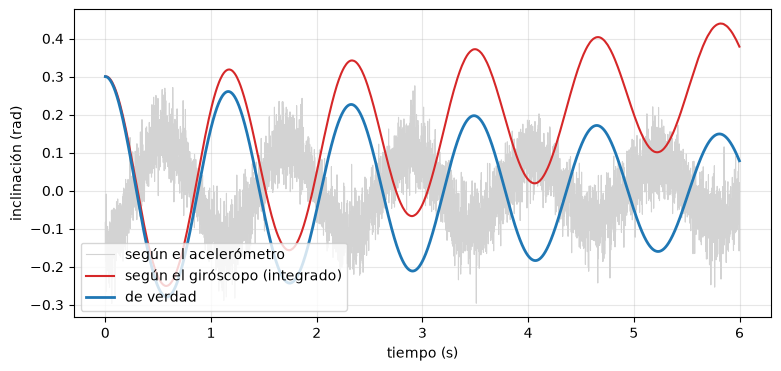

error del acelerómetro: 0.237 rad | del giróscopo: 0.173 rad


In [13]:
t = np.arange(len(verdad)) * 0.001
plt.figure(figsize=(9, 4))
plt.plot(t, inclinacion_acel, color="lightgray", lw=0.8, label="según el acelerómetro")
plt.plot(t, inclinacion_giro, color="tab:red", label="según el giróscopo (integrado)")
plt.plot(t, verdad, color="tab:blue", lw=2, label="de verdad")
plt.xlabel("tiempo (s)")
plt.ylabel("inclinación (rad)")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

def error_medio(estimacion):
    return np.sqrt(np.mean((estimacion - verdad) ** 2))      # la raíz del error cuadrático medio (NB28)

print(f"error del acelerómetro: {error_medio(inclinacion_acel):.3f} rad | del giróscopo: {error_medio(inclinacion_giro):.3f} rad")

Las dos estimaciones fallan, cada una a su manera:

- El **acelerómetro** (gris) está lleno de **ruido**, y además está **engañado** por el movimiento: el péndulo de verdad (azul) oscila entre ±0,3 rad, pero el acelerómetro marca oscilaciones más **pequeñas** y del signo **contrario**: ¡cuando el péndulo está inclinado hacia un lado, el acelerómetro dice que está inclinado hacia el otro! Mientras el péndulo se balancea, la bolita del acelerómetro nota la aceleración del balanceo **mezclada** con la gravedad, y el atan2 ya no mide la inclinación.
- El **giróscopo** (rojo) sigue la **forma** del balanceo perfectamente, suave y sin ruido apreciable... pero se va **desviando**, cada vez más arriba: el sesgo de 0,05 rad/s, sumado durante 6 segundos, son 0,3 rad de deriva. Si dejáramos pasar un minuto, estaría a 3 radianes.


## 5 · El filtro complementario: lo mejor de cada uno

La idea para combinarlos es preciosa, y cabe en una línea. En cada instante:

```
   estimación = 0,999 × (estimación anterior + giróscopo × tiempo)  +  0,001 × acelerómetro
                ───────────────────────────────────────────────────    ─────────────────────
                casi todo: lo que dice el giróscopo (suave, rápido)     un pellizco: el acelerómetro
```

- El **99,9 %** viene del giróscopo: a corto plazo manda él, y por eso la estimación es suave y sigue los movimientos rápidos.
- El **0,1 %** viene del acelerómetro, en **cada** instante. Un pellizco tan pequeño casi no deja pasar su ruido ni sus engaños de un momento, pero, como se repite mil veces por segundo, va **tirando** de la estimación hacia la inclinación de verdad **a la larga** y **corrige la deriva** del giróscopo antes de que se acumule.

¿Cuánto es "a la larga"? Un truco para saberlo: el acelerómetro tarda en corregir, más o menos, **paso ÷ (1 − peso)**. Aquí, 0,001 ÷ 0,001 = **1 segundo**. Es lo bastante largo para que sus engaños se compensen (mientras el péndulo se balancea, el acelerómetro se equivoca unas veces hacia un lado y otras hacia el otro: en un segundo pasa casi un balanceo entero) y lo bastante corto para que la deriva del giróscopo no tenga tiempo de crecer. (En muchos sitios verás el filtro complementario con un peso de **0,98**: es para robots que miden 100 veces por segundo, con pasos de 0,01 s, y da 0,01 ÷ 0,02 = medio segundo. Lo que importa no es el peso, sino ese **tiempo de corrección**.)

Se llama **filtro complementario**, porque usa a cada sensor para lo que se le da bien. Es un bucle sencillo:


In [14]:
def filtro_complementario(giro, acel, inicial, peso=0.999, paso=0.001):
    estimacion = [inicial]
    for i in range(1, len(giro)):
        prediccion = estimacion[-1] + giro[i] * paso              # lo que dice el giróscopo
        estimacion.append(peso * prediccion + (1 - peso) * acel[i])   # corregido un pelín con el acelerómetro
    return np.array(estimacion)

inclinacion_filtro = filtro_complementario(giroscopo_real, inclinacion_acel, 0.3)

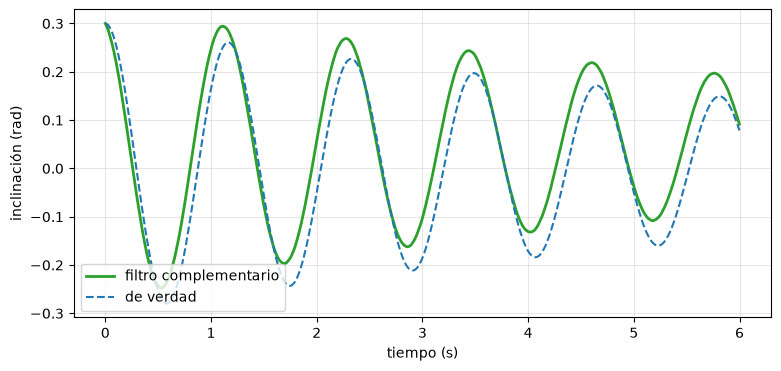

error del filtro complementario: 0.061 rad


In [15]:
plt.figure(figsize=(9, 4))
plt.plot(t, inclinacion_filtro, color="tab:green", lw=2, label="filtro complementario")
plt.plot(t, verdad, "--", color="tab:blue", label="de verdad")
plt.xlabel("tiempo (s)")
plt.ylabel("inclinación (rad)")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()
print(f"error del filtro complementario: {error_medio(inclinacion_filtro):.3f} rad")

El filtro **no** se desvía (el acelerómetro lo mantiene a raya) y sigue la forma del balanceo (gracias al giróscopo). No es perfecto: va un pelín desplazado hacia arriba (lo que el acelerómetro no ha llegado a corregir del sesgo) y algo adelantado. Pero su error, 0,061 rad, es casi **tres veces menor** que el del mejor de los dos sensores por separado. Dos sensores malos, bien combinados, dan una medida **buena**. Esta idea se llama **fusión de sensores**.

El 0,999 es otro número para **ajustar** (como Kp y Kd en el NB40): más cerca de 1, más confianza en el giróscopo (más suave, pero corrige la deriva más despacio); más lejos, más confianza en el acelerómetro (corrige antes, pero deja pasar más ruido). Lo explorarás en el ejercicio E4.

El filtro complementario es la versión sencilla de un método más potente y famosísimo, el **filtro de Kalman** (de 1960; guió las naves del programa Apolo hasta la Luna). Hace la misma idea, "predecir con un sensor y corregir con otro", pero calcula **él solo** cuánto fiarse de cada uno en cada momento, según lo ruidosos que sean. Los robots reales usan versiones del filtro de Kalman para estimar su orientación y su velocidad, combinando la IMU, los codificadores y los contactos de los pies.


## 6 · Sensores de fuerza: sentir el suelo

El último tipo de sensor importante para un robot con patas: los que miden la **fuerza** con la que el suelo empuja los **pies** (la fuerza normal del NB37). Pueden ser **sensores de fuerza** en los tobillos o en las suelas, o simplemente **interruptores** que dicen "este pie toca / no toca". O incluso ninguno: con actuadores cuasi-directos (NB40), el robot puede **estimar** las fuerzas mirando la corriente de sus motores.

Saber **qué pie está apoyado** es crucial: en el NB39 vimos que la física es completamente distinta según dónde esté el apoyo. Un robot que cree que tiene el pie en el suelo cuando no lo tiene, se cae.

MuJoCo calcula todas las fuerzas de contacto. Pongamos a Hopper de pie con el PD del NB40 y preguntémosle cuánto empuja el suelo. Primero, Hopper sostenido:


In [16]:
import gymnasium as gym

hopper = gym.make("Hopper-v5")
modelo_h = hopper.unwrapped.model
datos_h = hopper.unwrapped.data

hopper.reset(seed=0)
datos_h.qpos[:] = [0.0, 1.25, 0.0, 0.0, 0.0, 0.0]
datos_h.qvel[:] = 0
mujoco.mj_forward(modelo_h, datos_h)
datos_h.qpos[1] -= datos_h.joint("foot_joint").xanchor[2] - 0.0605          # pie apoyado (NB38)
for i in range(1500):
    par = 300 * (0 - datos_h.qpos[3:6]) - 20 * datos_h.qvel[3:6]           # el PD del NB40
    datos_h.ctrl[:] = np.clip(par / 200, -1, 1)
    mujoco.mj_step(modelo_h, datos_h)

En `datos_h.contact` está la lista de **contactos** que hay en este instante (cada punto en el que dos piezas se tocan), y `mujoco.mj_contactForce` calcula la fuerza de cada uno. Su primer número es la fuerza **perpendicular** a la superficie: la fuerza normal:

In [17]:
fuerza = np.zeros(6)
total = 0.0
for i in range(datos_h.ncon):
    contacto = datos_h.contact[i]
    mujoco.mj_contactForce(modelo_h, datos_h, i, fuerza)
    pieza1 = mujoco.mj_id2name(modelo_h, mujoco.mjtObj.mjOBJ_GEOM, contacto.geom1)
    pieza2 = mujoco.mj_id2name(modelo_h, mujoco.mjtObj.mjOBJ_GEOM, contacto.geom2)
    print(f"contacto entre {pieza1} y {pieza2}: {fuerza[0]:.1f} N")
    total = total + fuerza[0]

print(f"total: {total:.1f} N   |   peso de Hopper: {modelo_h.body_mass.sum() * 9.81:.1f} N")

contacto entre floor y foot_geom: 96.0 N
contacto entre floor y foot_geom: 59.2 N
total: 155.2 N   |   peso de Hopper: 155.2 N


Dos puntos de contacto entre el suelo (`floor`) y el pie (`foot_geom`), uno hacia el talón y otro hacia la punta, que suman **exactamente su peso**: 155 N, como predijimos en el NB37 ("si el robot está quieto, el sensor del pie marca su peso"). Y fíjate en que **no** empujan igual: el reparto entre talón y punta depende de dónde esté el centro de masas (NB38). Con estos dos números, el robot sabría dónde está su **centro de presión** (el ZMP del NB39). Así es como los robots reales comprueban que el ZMP está dentro del pie.


## 7 · El enemigo silencioso: el retraso

Todo sensor tarda algo en medir, la medida tarda en llegar al ordenador, el ordenador tarda en calcular, y la orden tarda en llegar al motor. En un robot real, desde que algo pasa hasta que el motor reacciona pueden pasar **varios milisegundos**, y a veces decenas. Y lo hemos visto en la sección 2: **suavizar** el ruido añade todavía más retraso.

¿Importa? Volvamos a la pierna del NB40, con su PD con compensación de gravedad, pero ahora el controlador ve el ángulo y la velocidad **con retraso**: los de hace unos milisegundos. Guardamos las medidas en una lista y el controlador lee las de hace `retraso` pasitos:


In [18]:
g = 9.81
masa, largo = 2.0, 0.5
inercia = masa * largo ** 2 / 3
paso = 0.001

def pierna_con_retraso(Kp, Kd, retraso_ms, duracion=3.0, objetivo=0.8):
    theta, velocidad = 0.0, 0.0
    historial = [(0.0, 0.0)] * (retraso_ms + 1)          # las medidas de los últimos milisegundos
    angulos = []
    for i in range(round(duracion / paso)):
        historial.append((theta, velocidad))
        theta_visto, velocidad_vista = historial[-1 - retraso_ms]     # ¡lo que ve el controlador es de hace un rato!
        par = Kp * (objetivo - theta_visto) - Kd * velocidad_vista + masa * g * (largo / 2) * math.sin(theta_visto)
        aceleracion = (par - masa * g * (largo / 2) * math.sin(theta)) / inercia
        velocidad = velocidad + aceleracion * paso
        theta = theta + velocidad * paso
        angulos.append(theta)
    return np.array(angulos)

(Cada pasito es 1 ms, así que un retraso de 20 pasitos son 20 milisegundos.) Probemos el PD rígido del NB40 (Kp = 200, Kd = 6) con retrasos crecientes, y miremos el último medio segundo: si está quieto en 0,8, el mínimo y el máximo serán 0,8:

In [19]:
for retraso in [0, 10, 20, 30]:
    angulos = pierna_con_retraso(200, 6, retraso)
    final = angulos[-500:]
    print(f"retraso {retraso:2d} ms:  último medio segundo entre {final.min():8.3f} y {final.max():8.3f} rad")

retraso  0 ms:  último medio segundo entre    0.800 y    0.800 rad
retraso 10 ms:  último medio segundo entre    0.800 y    0.800 rad
retraso 20 ms:  último medio segundo entre    0.696 y    0.909 rad
retraso 30 ms:  último medio segundo entre -47099424193.399 y 94394375133.528 rad


- **0 y 10 ms**: perfecto, quieto en 0,8.
- **20 ms**: ya no se queda quieto: **oscila** sin parar entre 0,7 y 0,9.
- **30 ms**: ¡**explota**! Las oscilaciones crecen y crecen hasta números absurdos (la pierna daría vueltas como un molinillo).

¿Por qué? El controlador reacciona a lo que pasaba **hace un rato**. Cuando por fin empuja hacia atrás porque la pierna se había pasado, la pierna ya está volviendo, y el empujón llega tarde y la **lanza** al otro lado. Es como intentar ducharte con un grifo que tarda 5 segundos en cambiar la temperatura: abres el caliente, no notas nada, abres más, de repente te quemas, cierras de golpe, te congelas... Y cuanto más **rígido** el controlador (Kp más alto), más fuerte reacciona y peor le sienta el retraso. Con el PD blando (Kp = 50, Kd = 3), el mismo retraso de 30 ms no le hace nada:


In [20]:
angulos = pierna_con_retraso(50, 3, 30)
print(f"Kp = 50 con 30 ms: entre {angulos[-500:].min():.3f} y {angulos[-500:].max():.3f} rad")

Kp = 50 con 30 ms: entre 0.800 y 0.800 rad


Por eso en los robots reales se cuida muchísimo la **latencia** (el retraso), y por eso los controladores de bajo nivel corren **tan deprisa** (a 1.000 veces por segundo o más) y tan **cerca** del motor (en la propia electrónica del motor, sin pasar por el ordenador principal).


## 8 · ¿Y la política de RL?

Llegamos al experimento que asusta. El Hopper campeón del NB35 sacaba **3.559 puntos**. Se entrenó en Gymnasium, con observaciones **perfectas**: sus 11 números son `qpos` y `qvel` exactos, información privilegiada. ¿Qué le pasa si le damos sus observaciones con un **poquito** de ruido, como si las midiera con sensores?

Cargamos el agente como en el NB35, y jugamos 10 episodios por cada nivel de ruido, sumando a cada observación números al azar de una campana:


In [21]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize

agente = PPO.load("modelos/Hopper-v5_defecto")
normalizador = VecNormalize.load("modelos/Hopper-v5_defecto_norm.pkl", make_vec_env("Hopper-v5", n_envs=1))
normalizador.training = False

def jugar_con_ruido(ruido, n=10):
    rng = np.random.default_rng(0)
    retornos, distancias = [], []
    for semilla in range(n):
        observacion, info = hopper.reset(seed=semilla)
        retorno = 0.0
        while True:
            observacion_ruidosa = observacion + rng.normal(0, ruido, observacion.shape)     # el "sensor"
            accion = agente.predict(normalizador.normalize_obs(observacion_ruidosa), deterministic=True)[0]
            observacion, recompensa, terminado, truncado, info = hopper.step(accion)
            retorno = retorno + recompensa
            if terminado or truncado:
                break
        retornos.append(retorno)
        distancias.append(info["x_position"])
    return np.mean(retornos), np.mean(distancias)

In [22]:
for ruido in [0.0, 0.01, 0.05, 0.1]:
    retorno, distancia = jugar_con_ruido(ruido)
    print(f"ruido {ruido:4.2f}:  retorno {retorno:7.1f}  |  recorre {distancia:5.2f} m")

ruido 0.00:  retorno  3558.8  |  recorre 20.73 m


ruido 0.01:  retorno  2915.4  |  recorre 17.08 m


ruido 0.05:  retorno   798.1  |  recorre  4.58 m


ruido 0.10:  retorno   318.4  |  recorre  1.67 m


Sin ruido, el campeón de siempre: 3.559 puntos y casi 21 metros. Con un ruido de **0,01** (un error típico de una centésima: ¡medio grado en los ángulos!), ya pierde **más de 600 puntos**. Con **0,05**, se **hunde**: unos 800 puntos, menos de 5 metros. Con **0,1**, apenas avanza metro y medio. La política se ha vuelto **frágil**: aprendió a confiar en números perfectos y a hacer movimientos "al límite" (los zigzags del NB35) que solo funcionan si sabe **exactamente** dónde está.

Esto es el **reality gap** en estado puro, y es lo primero que aprende cualquiera que intenta llevar una política de simulación a un robot real. Los remedios que se usan en la industria:

1. **Entrenar con ruido.** Si al entrenar se añade ruido a las observaciones, la política aprende a **no fiarse** de cada número suelto, a moverse con más margen y a ser robusta. Igual con los **retrasos**: se meten retrasos aleatorios en la simulación.
2. **Aleatorizar el mundo** (*domain randomization*, NB02): masas, rozamientos, fuerzas de los motores, ruido de sensores... todo un poco distinto en cada episodio, para que la política funcione en **cualquier** mundo parecido, incluido el real.
3. **Darle solo lo que un robot real puede medir**: ángulos de los codificadores, la IMU, los contactos. Nada de posición exacta del torso ni de su velocidad exacta.
4. **Profesor y alumno** (*teacher-student*): primero se entrena una política "profesora" **con** información privilegiada (aprende rápido y bien), y después se entrena una política "alumna" que solo ve lo que miden los sensores reales y aprende a **imitar** a la profesora (la imitación del NB18). Así se entrenaron muchos de los robots de cuatro patas más impresionantes de los últimos años.

Lo practicaremos de verdad en la parte de bípedos. Lo que te tienes que llevar hoy: **una política que no ha visto ruido nunca, no sobrevive al mundo real**.


## 9 · Resumen de la lección

1. Un robot real no tiene `qpos`/`qvel`: tiene **sensores**, con **ruido**, **sesgo**, **retraso** y **resolución** limitada. Lo que solo sabe el simulador es **información privilegiada**.
2. **Codificador**: disco con rayas; 4.096 posiciones por vuelta → 0,088°. Muy bueno para ángulos.
3. La **velocidad** por diferencias salta a escalones (0 ↔ 1,53 rad/s): **derivar amplifica los errores** (por eso Kd alto amplifica el ruido).
4. El **ruido** gaussiano se reduce **promediando**: n medidas → ruido / √n. La **media móvil** suaviza, pero añade **retraso**.
5. **IMU** = acelerómetro + giróscopo. El **acelerómetro** quieto mide la gravedad (9,81 "hacia arriba") → inclinación con atan2; en movimiento, se confunde. El **giróscopo** mide la velocidad de giro; integrado, se **desvía** por su sesgo (deriva).
6. En un péndulo de MuJoCo (`site`, `accelerometer`, `gyro`): quieto, el acelerómetro da la inclinación exacta; balanceándose, falla (hasta de signo); el giróscopo con sesgo se desvía.
7. **Filtro complementario** (99,9 % giróscopo + 0,1 % acelerómetro en cada milésima: corrige en ~1 s): suave, sin deriva, mucho mejor que cada sensor solo (0,061 rad de error frente a 0,237 y 0,173). **Fusión de sensores**; su versión potente es el **filtro de Kalman**.
8. **Sensores de fuerza**: el suelo empuja a Hopper en dos puntos que suman su peso (155 N); con ellos se calcula el centro de presión (ZMP).
9. **Retraso**: con 20-30 ms, un PD rígido oscila o explota; uno blando aguanta más. Los controladores de bajo nivel van muy rápido y cerca del motor.
10. La política del NB35 con ruido en la observación se hunde (3.559 → ~2.900 con 0,01 → ~800 con 0,05). Remedios: **entrenar con ruido y retrasos**, **aleatorizar**, solo observaciones **medibles**, **profesor-alumno**.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Sensor** | Aparato que mide algo del robot o del mundo. |
| **Información privilegiada** | Lo que sabe el simulador pero un robot real no puede medir. |
| **Codificador (*encoder*)** | Sensor de ángulo que cuenta rayas de un disco. |
| **Resolución** | El escalón más pequeño que puede distinguir un sensor. |
| **Ruido** | Errores al azar en cada medida. |
| **Sesgo (*bias*)** | Error que siempre va hacia el mismo lado. |
| **Media móvil** | Promedio de las últimas medidas: suaviza, pero retrasa. |
| **IMU** | Unidad de medida inercial: acelerómetro + giróscopo (el "oído interno"). |
| **Acelerómetro** | Mide la aceleración, con la gravedad incluida (quieto: 9,81 hacia arriba). |
| **Giróscopo** | Mide la velocidad de giro. |
| **Integrar** | Sumar a lo largo del tiempo (velocidad → ángulo). |
| **Deriva** | Error que crece sin parar al integrar un sesgo. |
| **Fusión de sensores** | Combinar sensores para obtener una medida mejor que la de cada uno. |
| **Filtro complementario / de Kalman** | Fusión sencilla (pesos fijos) / óptima (pesos calculados). |
| **`site` / `sensor`** | En MJCF: un punto marcado en una pieza / la sección de los sensores. |
| **Contacto / `mj_contactForce`** | Punto donde se tocan dos piezas / la fuerza en él. |
| **Latencia** | El retraso entre que algo pasa y el robot reacciona. |
| **Profesor-alumno (*teacher-student*)** | Entrenar con información privilegiada y luego imitar sin ella. |


## 10 · Ejercicios

**E1.** Un codificador tiene 1.024 posiciones por vuelta y va **antes** de una reductora de 50:1. ¿Qué resolución tiene, en grados, en la **articulación**?

**E2.** Un sensor tiene un ruido de 0,2. ¿Cuántas medidas tienes que promediar para que el ruido baje a 0,05? Compruébalo con NumPy.

**E3.** Un giróscopo tiene un sesgo de 0,01 rad/s (cinco veces menor que el de la sección 4). Si lo integras durante una partido de fútbol de robots (10 minutos), ¿cuánto se habrá desviado el ángulo? ¿Y en grados?

**E4.** Repite el filtro complementario de la sección 5 con pesos de 0,98, 0,999 y 0,9999. ¿Con cuál sale menos error? ¿Por qué empeoran los extremos? Calcula el tiempo de corrección de cada uno.

**E5.** Con `pierna_con_retraso`, busca el retraso más grande (de 5 en 5 ms) que aguanta sin oscilar el PD con Kp = 100, Kd = 4.

**E6.** **Reto.** Con `jugar_con_ruido`, añade el ruido **solo** a las velocidades (los 6 últimos números de la observación de Hopper, NB35) y no a las posiciones (los 5 primeros). ¿Le afecta más o menos que el ruido en todo? ¿Qué te dice eso?


<details>
<summary>▶ Solución E1</summary>

En el motor: 360° / 1.024 ≈ 0,352°. Como la articulación gira 50 veces menos que el motor, cada escalón del motor es un escalón 50 veces más pequeño en la articulación: 0,352 / 50 ≈ **0,007°**. Las reductoras, además de multiplicar el par, multiplican la precisión del codificador.

```python
print(round(360 / 1024 / 50, 4), "grados")
```
</details>

<details>
<summary>▶ Solución E2</summary>

Queremos dividir el ruido entre 4 (de 0,2 a 0,05), y el ruido se divide entre √n: √n = 4, así que **n = 16** medidas.

```python
promedios = (rng.normal(0, 0.2, (10000, 16))).mean(axis=1)
print(round(promedios.std(), 4))
```

Sale unos 0,05. Fíjate en lo caro que es: para dividir el ruido entre 4 hacen falta 16 medidas; para dividirlo entre 10, 100. Promediar es útil, pero cada mejora cuesta cada vez más.
</details>

<details>
<summary>▶ Solución E3</summary>

Deriva = sesgo × tiempo = 0,01 rad/s × 600 s = **6 radianes**, unos **344 grados**: ¡casi una vuelta entera! Un robot que solo confiara en su giróscopo, al final del partido creería que está boca abajo. Por eso **ningún** robot integra el giróscopo a ciegas: siempre se fusiona con algo que no se desvíe (el acelerómetro, como en la sección 5).

```python
print(0.01 * 600, round(math.degrees(0.01 * 600)))
```
</details>

<details>
<summary>▶ Solución E4</summary>

```python
for peso in [0.98, 0.999, 0.9999]:
    estimacion = filtro_complementario(giroscopo_real, inclinacion_acel, 0.3, peso=peso)
    print(peso, round(error_medio(estimacion), 4))
```

El mejor de los tres es el del medio, **0,999** (error 0,061; tiempo de corrección 1 s). Con **0,98** (corrige en 0,05 s) se fía demasiado del acelerómetro: sigue sus engaños del balanceo y el error sube a 0,22, casi tanto como el acelerómetro solo. Con **0,9999** (corrige en 10 s) se fía demasiado del giróscopo: el acelerómetro apenas tira de la estimación y la **deriva** se le escapa (error 0,14). Es el mismo dilema de siempre (ruido frente a retraso o deriva): hay un punto medio que hay que **ajustar** para cada robot y cada pareja de sensores.
</details>

<details>
<summary>▶ Solución E5</summary>

```python
for retraso in range(0, 61, 5):
    final = pierna_con_retraso(100, 4, retraso)[-500:]
    quieto = final.max() - final.min() < 0.001
    print(retraso, "quieto" if quieto else "oscila")
```

Aguanta hasta **20 ms** y oscila a partir de 25: algo más que el de Kp = 200 (que con 20 ms ya oscilaba) y menos que el de Kp = 50 (que con 30 ms seguía quieto): cuanto más rígido el controlador, menos retraso tolera. Hay un compromiso: la rigidez hace que la pierna obedezca rápido y con precisión, pero la hace más sensible al retraso.
</details>

<details>
<summary>▶ Solución E6</summary>

```python
def jugar_con_ruido_en_velocidades(ruido, n=10):
    rng = np.random.default_rng(0)
    retornos = []
    for semilla in range(n):
        observacion, info = hopper.reset(seed=semilla)
        retorno = 0.0
        while True:
            observacion_ruidosa = observacion.copy()
            observacion_ruidosa[5:] += rng.normal(0, ruido, 6)       # solo las 6 velocidades
            accion = agente.predict(normalizador.normalize_obs(observacion_ruidosa), deterministic=True)[0]
            observacion, recompensa, terminado, truncado, info = hopper.step(accion)
            retorno += recompensa
            if terminado or truncado:
                break
        retornos.append(retorno)
    return np.mean(retornos)

for ruido in [0.01, 0.05, 0.1]:
    print(ruido, round(jugar_con_ruido_en_velocidades(ruido), 1))
```

Con el ruido **solo en las velocidades**, la política aguanta **mucho mejor** que con ruido en todo: los números que más le importan son las **posiciones** (altura, inclinación, ángulos), que el ruido de 0,05 cambia en proporción mucho más que a las velocidades (que son números más grandes, de varias unidades). Esto te dice dos cosas: que una política no confía igual en todas sus observaciones, y que medir bien la **postura** (con codificadores precisos y una buena IMU con fusión de sensores) es lo más urgente para llevarla a un robot real.
</details>


## 11 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

En esta parte hemos escrito ya varios planos de MuJoCo a mano: un péndulo, un bloque, un péndulo con IMU. En el **NB42** aprenderemos el lenguaje **MJCF** a fondo: cuerpos, articulaciones, geometrías, masas, motores de par y de posición (con su PD dentro), sensores... y construiremos, pieza a pieza, **un robot bípedo propio**, que en el NB43 intentaremos hacer andar.
